<a href="https://colab.research.google.com/github/gauravprajapati9210/Machine-Learning-Projects/blob/main/ANN_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ANN for Regression
# PowerPlant Dataset(Energy Industry )

import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


 AT --> Temperature
 v--> vaccum
 AP --> Pressure
 RH --> humidity
 PE --> Produced energy

In [ ]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [ ]:
x=df.drop("PE",axis=1)
y = df["PE"]



In [ ]:
x.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


important steps :-
1.Load the data
2.Data --> Tensors
3.TensorDataset & Data Loader
4.Define ANN model
5. Train the model
6.Evaluate

In [ ]:
#split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42 )

In [ ]:
# Preprocessing the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [ ]:
#Converting data to Tensors by using  pytorch core Ds
import torch
import torch.nn as nn
x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1) #.view used to convert dimensions

x_test_tensor = torch.tensor(x_test_scaled, dtype = torch.float32)
y_test_tensor=torch.tensor(y_test.values, dtype=torch.float32).view(-1,1) #.view used to convert dimensions


In [ ]:
type(x_train_scaled)

numpy.ndarray

In [ ]:
type(y_train)
y_train.shape

(7654,)

<!-- # Data Training done on batches -->
DataLoader class is used to create batches for us from dataset.
 It can suffle the data

#DataLoader class can't directly access memory .

 solve memory access another class TensorDataset class used to access the dataset.

 #IT CAN provide dataset one by one also




In [ ]:
from torch.utils.data import TensorDataset , DataLoader
train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

In [ ]:
train_loader =DataLoader(train_dataset,batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 32)


In [ ]:
# Deeplearning -->Define an ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            #First Hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
            #Second Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
            #final output layer
            nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)
    # Autograd is used to automatic gradient componenet - it auto handle backward propagation



In [ ]:
import torch.optim as optim
model = ANN()

# loss,optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
# Train the ANN
train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #tot loss for traning loss for 1 epochs
    for xb,yb in train_loader:
        # xb is features of one batch and yb labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop ... predicted outputs for this batch
        loss = crietrion (outputs,yb) #compute loss
        loss.backward() # backward prop... compute gradients
        optimizer.step() #params update
        running_loss += loss.item() # loss is a tensor
    epoch_train_loss = running_loss/ len(train_loader)
    train_losses.append(epoch_train_loss)

    # validtion
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model(xb) # forward prop ... predicted outputs for this batch
            loss = crietrion (outputs,yb) #compute loss
            running_val_loss += loss
    epoch_val_loss = running_val_loss/ len(test_loader)
    val_losses.append(epoch_val_loss)

    # print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val_loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") # .pt or .pth

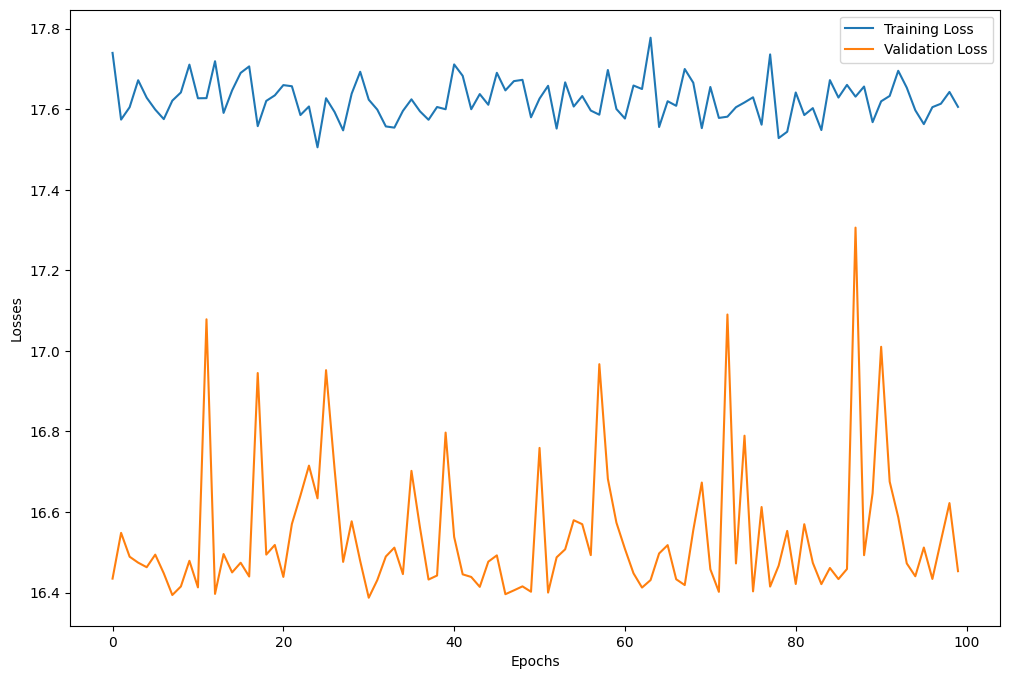

In [ ]:
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({
    "train_loss":train_losses,
    "Validation loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["train_loss"],label = "Training Loss")
plt.plot(loss_df["Validation loss"],label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [ ]:
# loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [ ]:
# Evaluate our model
model.eval()
with torch.no_grad():
    train_pred=model(x_train_tensor)
    test_pred=model(x_test_tensor)

    train_mse_loss = crietrion(train_pred,y_train_tensor)
    test_mse_loss = crietrion(test_pred,y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 17.47806739807129
Testing MSE: 16.396240234375


In [ ]:
from sklearn.metrics import r2_score
print("re score =",r2_score(y_test,test_pred))

re score = 0.9426993709392293


In [ ]:
pred_df=pd.DataFrame(test_pred.numpy(),columns = ["Predicted Values"])
actual_df= pd.DataFrame(y_test.values,columns = ["Actual Values"])
pd.concat([pred_df,actual_df],axis = 1)

,Predicted Values,Actual Values
0,435.011810,433.27
1,436.171173,438.16
2,460.541138,458.42
3,474.665405,480.82
4,436.459473,441.41
...,...,...
1909,449.826355,456.70
1910,432.785553,438.04
1911,467.348114,467.80
1912,433.405334,437.14
